In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
df = pd.read_csv("/content/healthcare_dataset (1).csv.xls")

In [88]:
df.head()

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date
0,P1001,Male,45,Hypertension,15-01-2026,Urgent,ICD-10-I10,4500.0,20-01-2026
1,P1002,Female,32,Pneumonia,16-01-2026,Emergency,ICD-10-J18,6700.5,22-01-2026
2,P1003,Male,68,Diabetes Type 2,16-01-2026,Routine,ICD-10-E11,3200.0,18-01-2026
3,P1004,Female,55,Asthma,17-01-2026,Emergency,ICD-10-J45,5800.0,19-01-2026
4,P1005,Male,29,Fracture,17-01-2026,Urgent,ICD-10-S52,8500.0,25-01-2026


In [89]:
df.shape

(500, 9)

In [90]:
df.describe()

,Age,Billing_Amount
count,500.000000,500.00000
mean,50.106000,7249.00100
std,15.328035,3198.96932
min,22.000000,2300.00000
25%,37.000000,4400.00000
50%,50.000000,6950.00000
75%,63.000000,9400.00000
max,78.000000,14200.00000


In [91]:
print(df.isnull().sum())

Patient_ID           0
Gender               0
Age                  0
Medical_Condition    0
Admission_Date       0
Admission_Type       0
Medical_Code         0
Billing_Amount       0
Discharge_Date       0
dtype: int64


In [92]:
df = df.dropna()

In [93]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], utc=True)
df["Admission_Date"].dtype

/tmp/ipykernel_1787/1185611985.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], utc=True)


datetime64[ns, UTC]

In [94]:
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], utc=True)
df["Discharge_Date"].dtype

/tmp/ipykernel_1787/2534537838.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], utc=True)


datetime64[ns, UTC]

In [95]:
df["Hospital_Stays"] = (df["Discharge_Date"] - df["Admission_Date"]).dt.days
df

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date,Hospital_Stays
0,P1001,Male,45,Hypertension,2026-01-15 00:00:00+00:00,Urgent,ICD-10-I10,4500.0,2026-01-20 00:00:00+00:00,5
1,P1002,Female,32,Pneumonia,2026-01-16 00:00:00+00:00,Emergency,ICD-10-J18,6700.5,2026-01-22 00:00:00+00:00,6
2,P1003,Male,68,Diabetes Type 2,2026-01-16 00:00:00+00:00,Routine,ICD-10-E11,3200.0,2026-01-18 00:00:00+00:00,2
3,P1004,Female,55,Asthma,2026-01-17 00:00:00+00:00,Emergency,ICD-10-J45,5800.0,2026-01-19 00:00:00+00:00,2
4,P1005,Male,29,Fracture,2026-01-17 00:00:00+00:00,Urgent,ICD-10-S52,8500.0,2026-01-25 00:00:00+00:00,8
...,...,...,...,...,...,...,...,...,...,...
495,P1496,Female,50,COPD,2026-09-20 00:00:00+00:00,Emergency,ICD-10-J44,9800.0,2026-09-23 00:00:00+00:00,3
496,P1497,Male,28,Fracture,2026-09-20 00:00:00+00:00,Urgent,ICD-10-S52,9400.0,2026-09-24 00:00:00+00:00,4
497,P1498,Female,67,Heart Attack,2026-09-21 00:00:00+00:00,Emergency,ICD-10-I21,14200.0,2026-09-25 00:00:00+00:00,4
498,P1499,Male,43,Diabetes Type 2,2026-09-21 00:00:00+00:00,Routine,ICD-10-E11,4900.0,2026-09-23 00:00:00+00:00,2


In [96]:
billing = df.groupby(["Medical_Condition", "Admission_Type"])["Billing_Amount"].sum().unstack()
billing

Admission_Type,Emergency,Routine,Urgent
Medical_Condition,,,
Allergic Reaction,NaN,NaN,58800.0
Anxiety Disorder,NaN,27800.0,NaN
Appendicitis,319400.0,NaN,NaN
Asthma,5800.0,NaN,92100.0
Back Pain,NaN,NaN,76800.0
COPD,296200.0,NaN,NaN
Diabetes Type 1,NaN,72300.0,NaN
Diabetes Type 2,NaN,66200.0,NaN
Fracture,NaN,NaN,188500.0


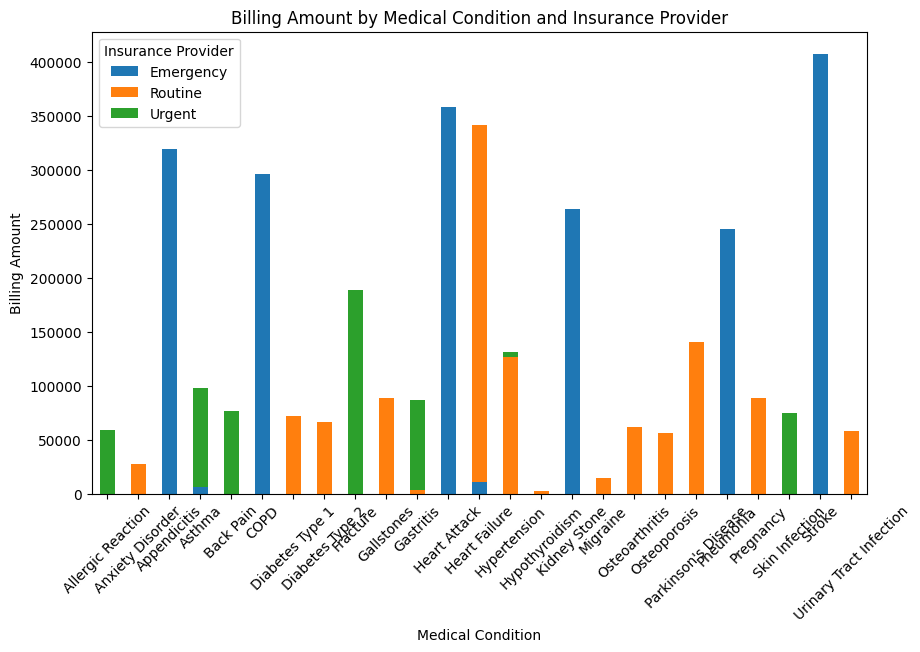

In [97]:
billing.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xticks(rotation=45)
plt.legend(title="Insurance Provider")
plt.show()

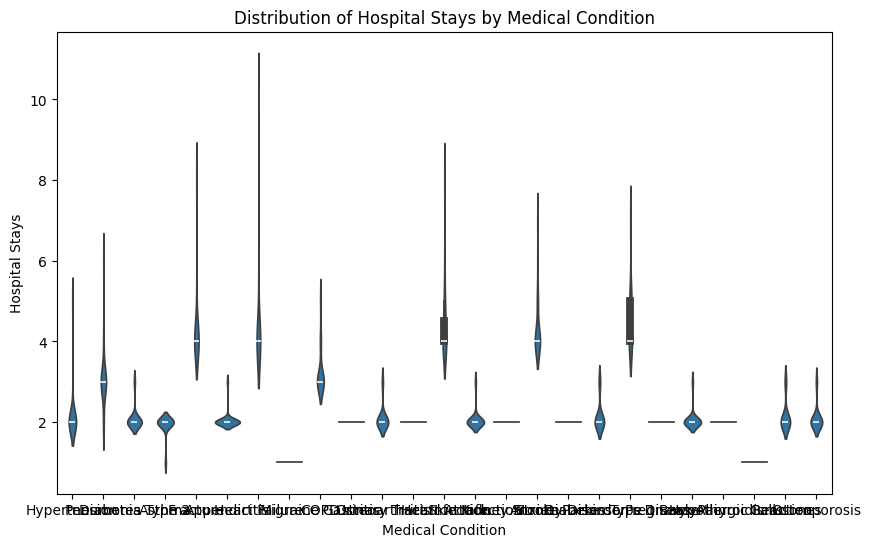

In [98]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    x="Medical_Condition",
    y="Hospital_Stays",
    data=df,
)
plt.title("Distribution of Hospital Stays by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Hospital Stays")
plt.show()

In [99]:
df["Hospital_Stays"] = (df["Discharge_Date"] - df["Admission_Date"]).dt.days
df

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date,Hospital_Stays
0,P1001,Male,45,Hypertension,2026-01-15 00:00:00+00:00,Urgent,ICD-10-I10,4500.0,2026-01-20 00:00:00+00:00,5
1,P1002,Female,32,Pneumonia,2026-01-16 00:00:00+00:00,Emergency,ICD-10-J18,6700.5,2026-01-22 00:00:00+00:00,6
2,P1003,Male,68,Diabetes Type 2,2026-01-16 00:00:00+00:00,Routine,ICD-10-E11,3200.0,2026-01-18 00:00:00+00:00,2
3,P1004,Female,55,Asthma,2026-01-17 00:00:00+00:00,Emergency,ICD-10-J45,5800.0,2026-01-19 00:00:00+00:00,2
4,P1005,Male,29,Fracture,2026-01-17 00:00:00+00:00,Urgent,ICD-10-S52,8500.0,2026-01-25 00:00:00+00:00,8
...,...,...,...,...,...,...,...,...,...,...
495,P1496,Female,50,COPD,2026-09-20 00:00:00+00:00,Emergency,ICD-10-J44,9800.0,2026-09-23 00:00:00+00:00,3
496,P1497,Male,28,Fracture,2026-09-20 00:00:00+00:00,Urgent,ICD-10-S52,9400.0,2026-09-24 00:00:00+00:00,4
497,P1498,Female,67,Heart Attack,2026-09-21 00:00:00+00:00,Emergency,ICD-10-I21,14200.0,2026-09-25 00:00:00+00:00,4
498,P1499,Male,43,Diabetes Type 2,2026-09-21 00:00:00+00:00,Routine,ICD-10-E11,4900.0,2026-09-23 00:00:00+00:00,2


In [100]:

df["Admission_Month"] = df["Admission_Date"].dt.to_period("M")


monthly_admissions = df.groupby("Admission_Month").size()
monthly_admissions

/tmp/ipykernel_1787/2844296141.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["Admission_Month"] = df["Admission_Date"].dt.to_period("M")


,0
Admission_Month,
2026-01,33
2026-02,56
2026-03,62
2026-04,60
2026-05,62
2026-06,60
2026-07,62
2026-08,62
2026-09,43


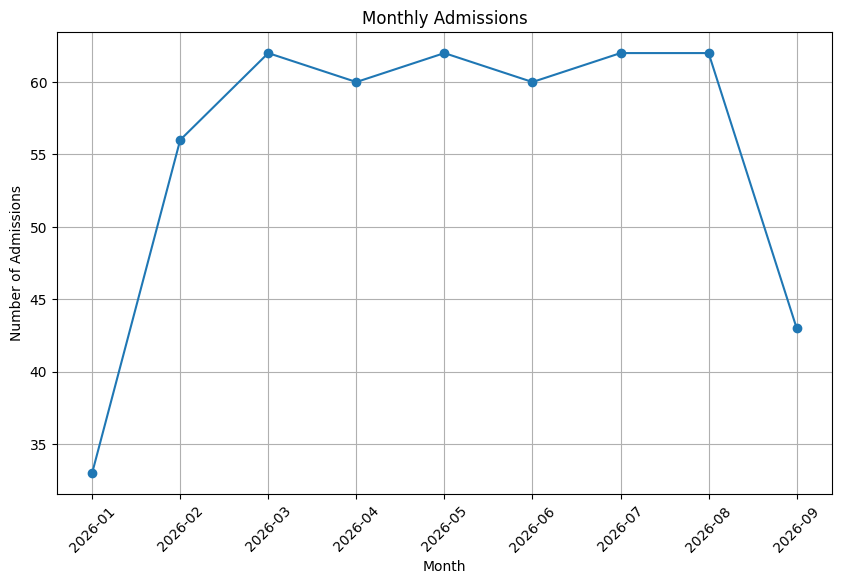

In [101]:
plt.figure(figsize=(10, 6))

monthly_admissions.index = monthly_admissions.index.astype(str)

monthly_admissions.plot(kind='line', marker='o')
plt.title('Monthly Admissions')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [102]:
correlation_matrix = df[['Age', 'Hospital_Stays', 'Billing_Amount']].corr()
correlation_matrix

,Age,Hospital_Stays,Billing_Amount
Age,1.000000,0.532377,0.455645
Hospital_Stays,0.532377,1.000000,0.652968
Billing_Amount,0.455645,0.652968,1.000000


In [103]:
correlation_matrix = df[['Age', 'Hospital_Stays', 'Billing_Amount']].corr()
correlation_matrix

,Age,Hospital_Stays,Billing_Amount
Age,1.000000,0.532377,0.455645
Hospital_Stays,0.532377,1.000000,0.652968
Billing_Amount,0.455645,0.652968,1.000000
